# SCANIA Component X: Exploratory Data Analysis (EDA)

This notebook explores the **SCANIA Component X Dataset**, a real dataset released for the IDA 2024 Industrial Challenge. The data come from a fleet of SCANIA trucks (Sweden) and focus on predictive maintenance (PdM) of an anonymized engine component ("Component X").

## 1. Domain Characteristics and Temporal Structure
* **System Type**: Industrial commercial vehicles operating under real-world conditions, not simulated.
* **Operational Data (Multivariate Time Series)**: Readings extracted from vehicle control units at specific time intervals (identified by `vehicle_id` and `time_step`).
* **Signals Present**: The sensors do not report only traditional continuous values, but are structured as **numeric counters** (cumulative values) and **histograms** (value distributions across specific ranges).
* **Target Variable (TTE)**: The training labels are stored in `train_tte.csv`, which contains two key columns: `length_of_study_time_step` (the operational time steps) and `in_study_repair` (the binary fault/replacement label).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style='whitegrid', palette='muted')

# 1. Load the labels and repair records (Time-To-Event)
# Make sure the file path matches your local directory
print("Loading the TTE file...")
train_tte = pd.read_csv('../data/train_tte.csv')

print(f"TTE file dimensions: {train_tte.shape}")
display(train_tte.head())


Loading the TTE file...
TTE file dimensions: (23550, 3)


,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


## 2. Target Distribution and Temporal Profiling
Industrial datasets are inherently imbalanced; normal operating conditions vastly outnumber actual equipment failures. Quantifying this disparity is a prerequisite for downstream sampling and evaluation strategies.

Alongside the raw imbalance, mapping the distribution of vehicle life cycles (Time-To-Event) reveals survival profiles, indicating whether failures tend to occur prematurely or follow long-term wear patterns compared to the healthy baseline.

Class counts:
Healthy components (Label 0): 21278
Repaired components (Label 1): 2272


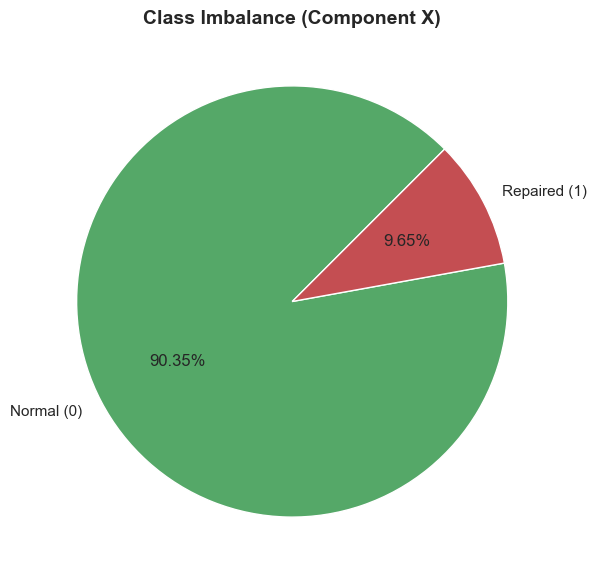

In [17]:
# Quantify the baseline class imbalance for the 'in_study_repair' target
class_counts = train_tte['in_study_repair'].value_counts().sort_index()

print("Class counts:")
print(f"Healthy components (Label 0): {class_counts[0]}")
print(f"Repaired components (Label 1): {class_counts[1]}")

# Visualize the failure rate imbalance
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    class_counts, 
    labels=['Normal (0)', 'Repaired (1)'], 
    colors=['#55A868', '#C44E52'], 
    autopct='%1.2f%%', 
    startangle=45,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Class Imbalance (Component X)', fontsize=14, fontweight='bold')
plt.show()

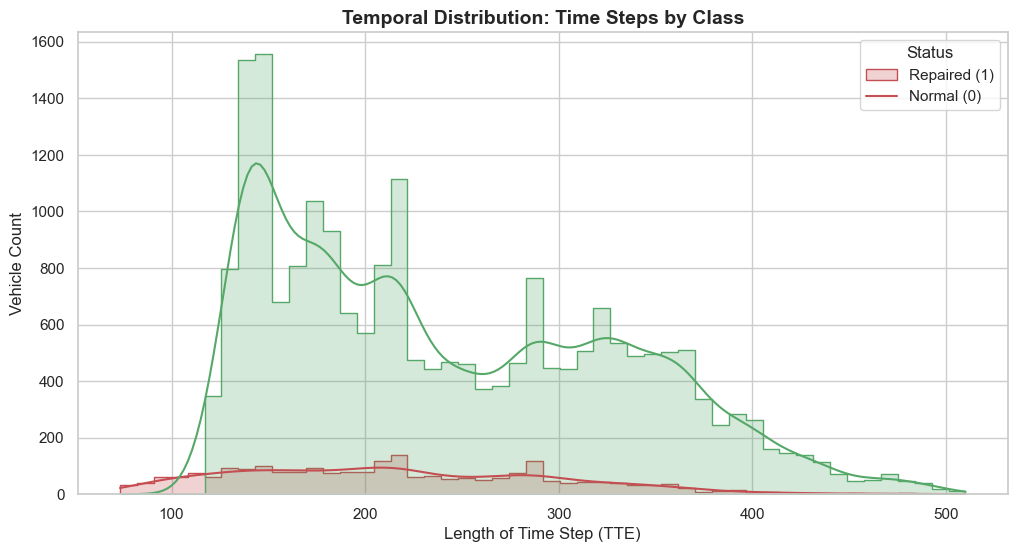

In [18]:
# Analyze the survival profiles: how long vehicles operate before end-of-study or failure
plt.figure(figsize=(12, 6))
sns.histplot(
    data=train_tte, 
    x='length_of_study_time_step', 
    hue='in_study_repair', 
    hue_order=[0, 1],
    bins=50, 
    kde=True, 
    palette=['#55A868', '#C44E52'],
    element='step'
)

plt.title('Temporal Distribution: Time Steps by Class', fontsize=14, fontweight='bold')
plt.xlabel('Length of Time Step (TTE)', fontsize=12)
plt.ylabel('Vehicle Count', fontsize=12)
plt.legend(title='Status', labels=['Repaired (1)', 'Normal (0)'])
plt.show()

## 3. Technical Specifications and Hardware Configurations
Beyond dynamic sensor data, each vehicle possesses a static profile representing its physical configuration (e.g., chassis type, weight class, or regional specification). Before integrating these specifications with the target labels, assessing data completeness is critical. Missing values are prevalent in heavy-industry datasets due to heterogeneous reporting standards across different vehicle generations or fleet managers.

After validating data quality, we merge the technical specifications with the TTE labels. This allows us to observe whether specific hardware configurations are disproportionately prone to failures, providing our first empirical hint of covariate shift across the fleet.

In [19]:
# Load the static vehicle configurations
print("Loading the Specifications file...")
train_specs = pd.read_csv('../data/train_specifications.csv')

print(f"Specifications file dimensions: {train_specs.shape}")
display(train_specs.head())

# Calculate the percentage of missing values per column
missing_specs = train_specs.isnull().mean() * 100
missing_specs = missing_specs[missing_specs > 0].sort_values(ascending=False)

# Visually profile missing data to determine if imputation or dropping is required
if not missing_specs.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_specs.index[:15], y=missing_specs.values[:15], palette='flare')
    plt.title('Missing Values in Technical Specifications (%)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('% Missing Data')
    plt.show()
else:
    print("No missing data detected in the technical specifications.")


Loading the Specifications file...
Specifications file dimensions: (23550, 9)


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


No missing data detected in the technical specifications.


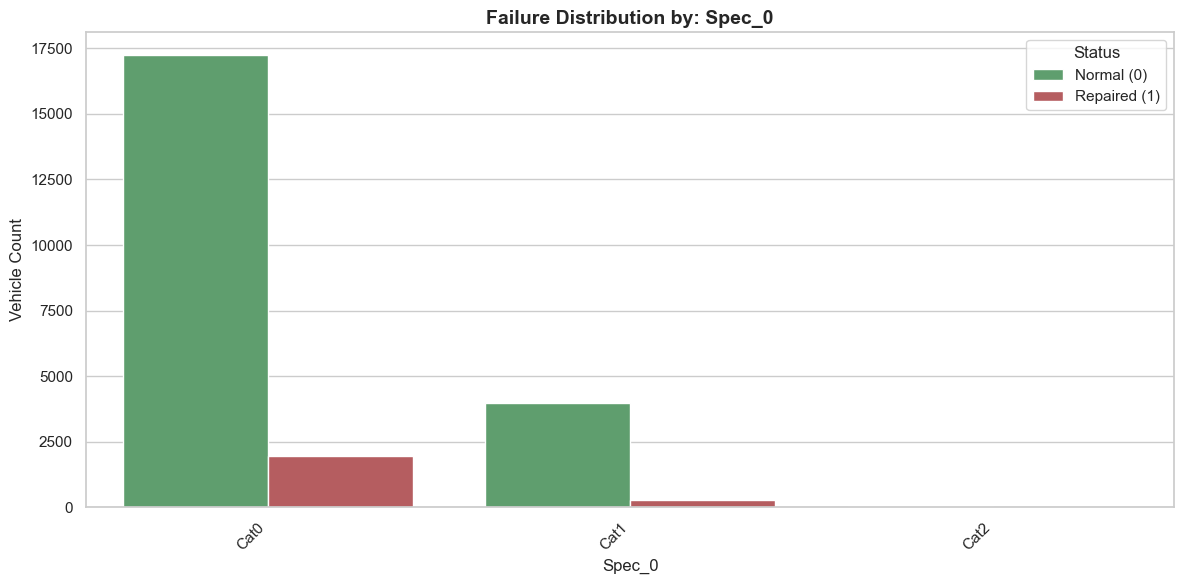

In [20]:
# Merge the static specifications with the failure labels via the unique vehicle identifier
df_specs_labels = pd.merge(train_specs, train_tte, on='vehicle_id', how='inner')

# Automatically identify a categorical column to analyze failure distributions across domains
cat_col = df_specs_labels.select_dtypes(include=['object']).columns[0] 

# Plot the breakdown of healthy vs. repaired components across different hardware specs
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_specs_labels, 
    x=cat_col, 
    hue='in_study_repair', 
    palette=['#55A868', '#C44E52']
)

plt.title(f'Failure Distribution by: {cat_col}', fontsize=14, fontweight='bold')
plt.xlabel(cat_col)
plt.ylabel('Vehicle Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', labels=['Normal (0)', 'Repaired (1)'])
plt.tight_layout()
plt.show()


## 4. Operational Data and Feature Categorization
The core of the SCANIA dataset lies in the longitudinal operational readouts collected from the vehicles' Electronic Control Units (ECUs). This multivariate time series data captures the dynamic state of the engine component over its lifecycle. 

A unique challenge in this dataset is the presence of multi-dimensional histograms. Rather than a single continuous value, certain sensors record the frequency of operations across various intensity bins (e.g., temperatures or RPMs). Before proceeding with deeper statistical analysis, we must systematically isolate these histogram bins from standard continuous counters using Regex pattern matching.

Following feature categorization, visualizing the longitudinal operational profiles of randomly sampled vehicles provides an intuitive understanding of how degradation signatures physically manifest over time.


In [21]:
import re

# Load the longitudinal sensor data
print("Loading the Operational Data file...")
train_op = pd.read_csv('../data/train_operational_readouts.csv')

print(f"Operational Data file dimensions: {train_op.shape}")
print(f"Number of unique vehicles monitored: {train_op['vehicle_id'].nunique()}")

# Inspect the format of the anonymized operational columns
display(train_op.head())

# Programmatically identify histogram-based features 
# SCANIA histograms are typically formatted with a prefix and a bin index (e.g., '167_0', '167_1')
hist_cols = [c for c in train_op.columns if re.match(r'^\d+_\d+$', c)]
prefixes = sorted(set(c.split('_')[0] for c in hist_cols))
print(f"Detected {len(prefixes)} unique histogram variables, spanning {len(hist_cols)} total bins.")


Loading the Operational Data file...
Operational Data file dimensions: (1122452, 107)
Number of unique vehicles monitored: 23550


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0


Detected 14 unique histogram variables, spanning 105 total bins.


Randomly sampled vehicle ID: 2995


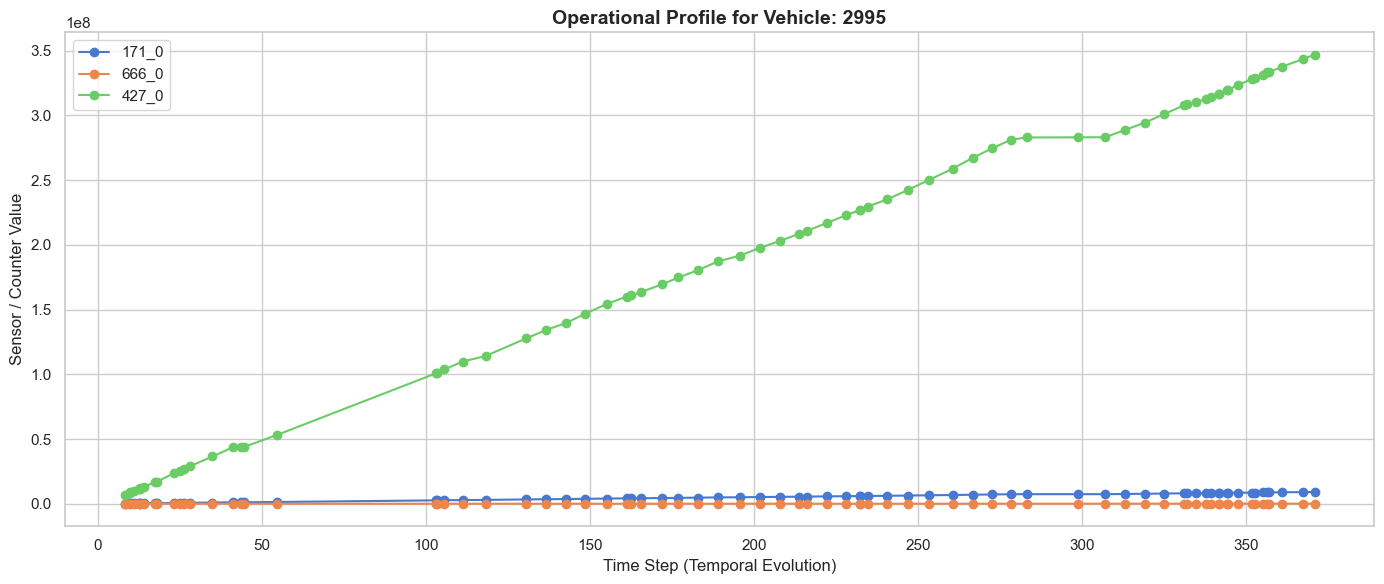

In [22]:
# Establish a random seed for reproducible sampling
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Sample a single vehicle to visualize its multivariate operational profile over time
sample_vehicle = rng.choice(train_op['vehicle_id'].unique())
df_sample = train_op[train_op['vehicle_id'] == sample_vehicle].sort_values('time_step')

print(f"Randomly sampled vehicle ID: {sample_vehicle}")

# Select a subset of numeric columns to avoid visual clutter
cols_to_plot = df_sample.select_dtypes(include=[np.number]).columns[2:5]

plt.figure(figsize=(14, 6))
for col in cols_to_plot:
    plt.plot(df_sample['time_step'], df_sample[col], marker='o', label=col)

plt.title(f'Operational Profile for Vehicle: {sample_vehicle}', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Temporal Evolution)', fontsize=12)
plt.ylabel('Sensor / Counter Value', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


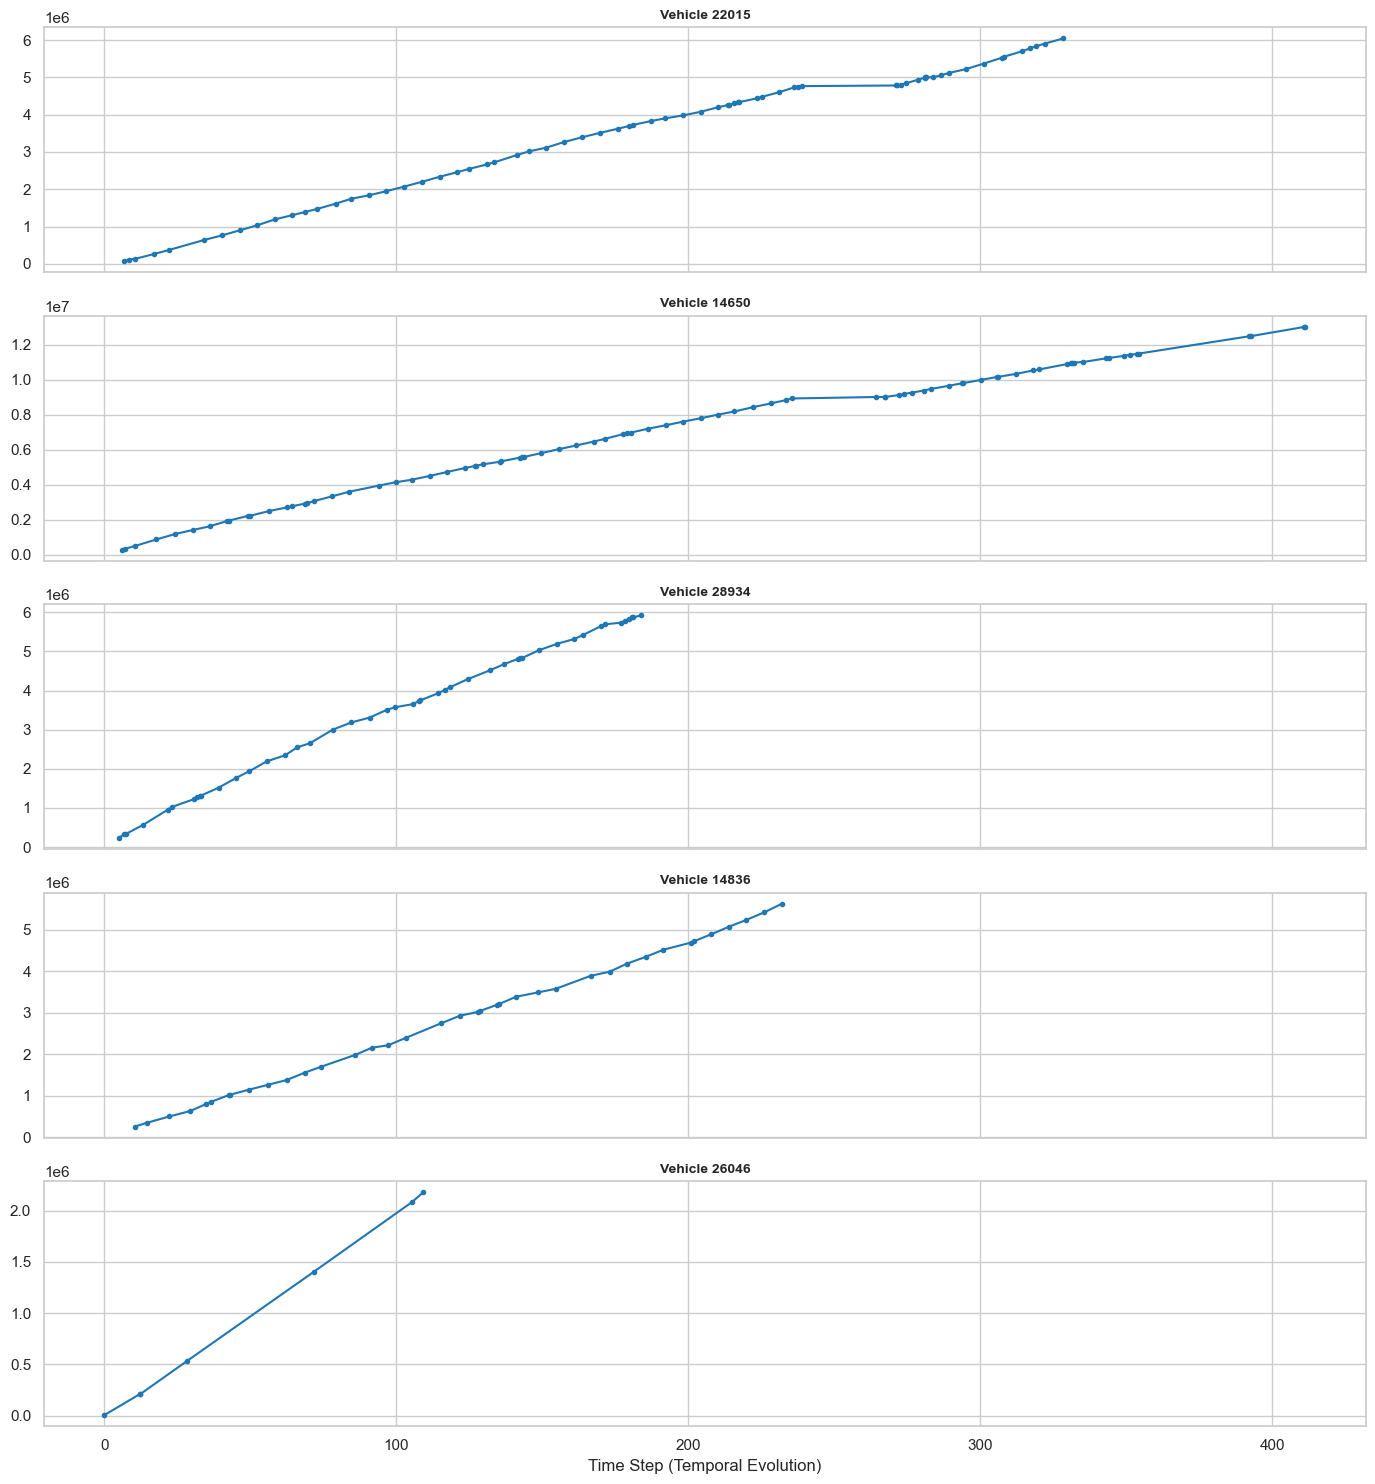

In [23]:
# Sample multiple vehicles to compare inter-vehicle operational variance on a single sensor
sample_vehicles = rng.choice(train_op['vehicle_id'].unique(), size=5, replace=False)

fig, axes = plt.subplots(len(sample_vehicles), 1, figsize=(14, 3*len(sample_vehicles)), sharex=True)
for ax, veh in zip(axes, sample_vehicles):
    df_v = train_op[train_op['vehicle_id'] == veh].sort_values('time_step')
    # Select a single continuous variable for direct cross-vehicle comparison
    col = df_v.select_dtypes(include=[np.number]).columns[2]  
    ax.plot(df_v['time_step'], df_v[col], marker='o', markersize=3, color='#1f77b4')
    ax.set_title(f'Vehicle {veh}', fontsize=10, fontweight='bold')

plt.xlabel('Time Step (Temporal Evolution)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Feature Selection and Statistical Relevance
To evaluate which sensors are most indicative of an impending failure, we must temporarily flatten the longitudinal data into a vehicle-level representation. By calculating the mean of all sensor readings over each vehicle's recorded lifespan, we can perform direct, per-vehicle statistical comparisons against the binary target.

We utilize **Mutual Information (MI)** to score feature relevance. Unlike standard Pearson correlation, MI captures both linear and complex non-linear relationships, which are highly typical in mechanical wear-and-tear degradation profiles. We then visualize the distributional shifts of the top-ranked sensors using boxplots, followed by a heatmap to investigate feature collinearity and redundancy.


In [24]:
print("Merging Operational Data with TTE labels...")

# Merge the dynamic sensor data with the target variables
df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')
print(f"Merged dataset dimensions: {df_merged.shape}")

# Verify the integration by displaying a subset of the joined dataframe
display(df_merged[['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']].head())


Merging Operational Data with TTE labels...
Merged dataset dimensions: (1122452, 109)


,vehicle_id,time_step,length_of_study_time_step,in_study_repair
0,0,11.2,510.0,0
1,0,11.4,510.0,0
2,0,19.6,510.0,0
3,0,20.2,510.0,0
4,0,21.0,510.0,0


In [25]:
from sklearn.feature_selection import mutual_info_classif

# Aggregate data to a vehicle-level format (mean of all readings over time)
numeric_cols = train_op.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ('vehicle_id', 'time_step')]

df_op_agg = train_op.groupby('vehicle_id')[numeric_cols].mean().reset_index()
print(f"Aggregated from {train_op.shape[0]} time-step rows to {df_op_agg.shape[0]} vehicle-level rows.")

# Merge with TTE labels — each row now represents an independent, full-lifecycle vehicle profile
df_vehicle_level = pd.merge(df_op_agg, train_tte, on='vehicle_id', how='inner')

# Impute missing values with 0 (standard for missing operational intervals) before applying MI
X = df_vehicle_level[numeric_cols].fillna(0)
y = df_vehicle_level['in_study_repair']

# Calculate Mutual Information scores to identify the most predictive features
mi_scores = pd.Series(
    mutual_info_classif(X, y, discrete_features=False, random_state=RANDOM_STATE),
    index=numeric_cols
).sort_values(ascending=False)

print("\nTop 10 features by Mutual Information with the target:")
print(mi_scores.head(10))

# Visualize the distributional shift of the top 4 MI features between healthy and repaired fleets
features_to_compare = mi_scores.head(4).index.tolist()

Aggregated from 1122452 time-step rows to 23550 vehicle-level rows.

Top 10 features by Mutual Information with the target:
158_9     0.009075
309_0     0.007911
167_6     0.007763
459_9     0.007170
158_6     0.006390
837_0     0.005963
158_8     0.005807
397_32    0.005768
397_13    0.005765
167_3     0.005661
dtype: float64


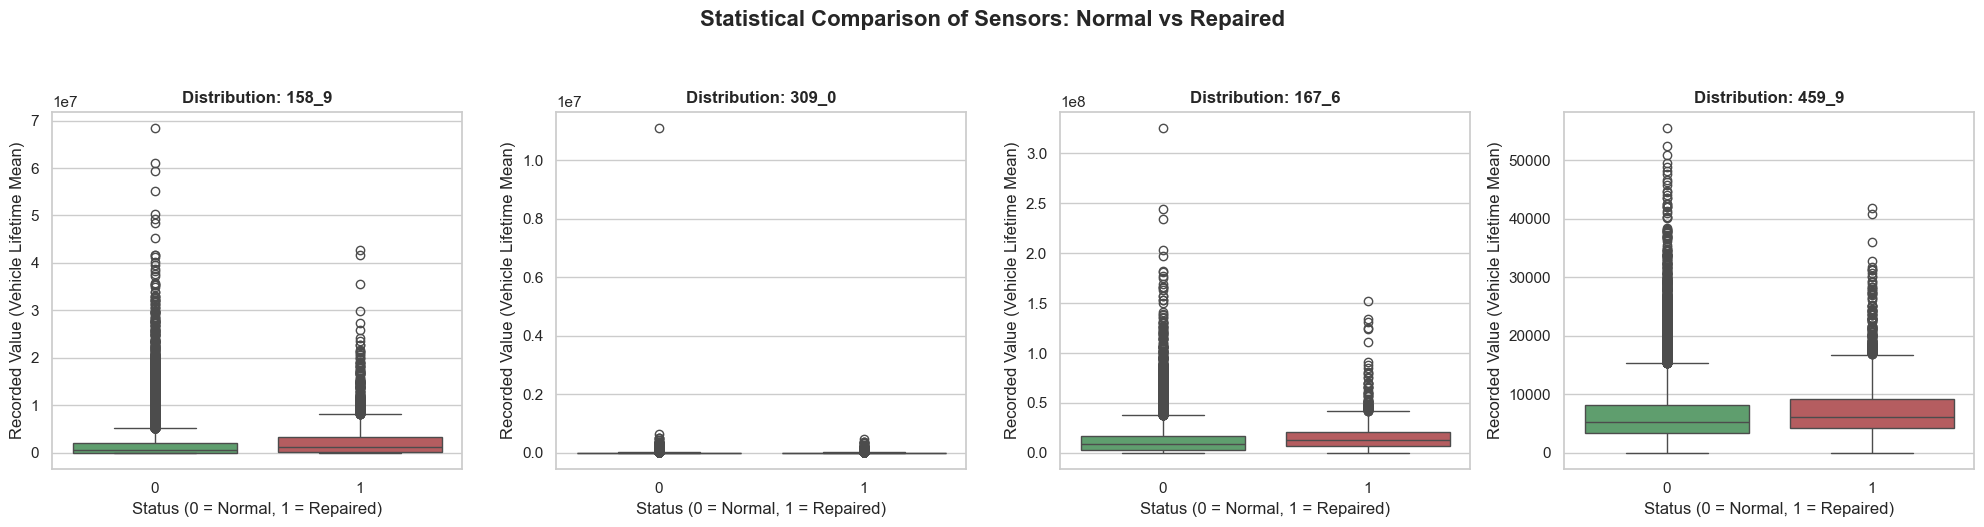

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        x='in_study_repair', 
        y=feature, 
        data=df_vehicle_level, 
        ax=axes[i], 
        hue='in_study_repair',
        palette=['#55A868', '#C44E52'],
        legend=False
    )
    axes[i].set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Status (0 = Normal, 1 = Repaired)')
    axes[i].set_ylabel('Recorded Value (Vehicle Lifetime Mean)')

plt.suptitle('Statistical Comparison of Sensors: Normal vs Repaired', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()




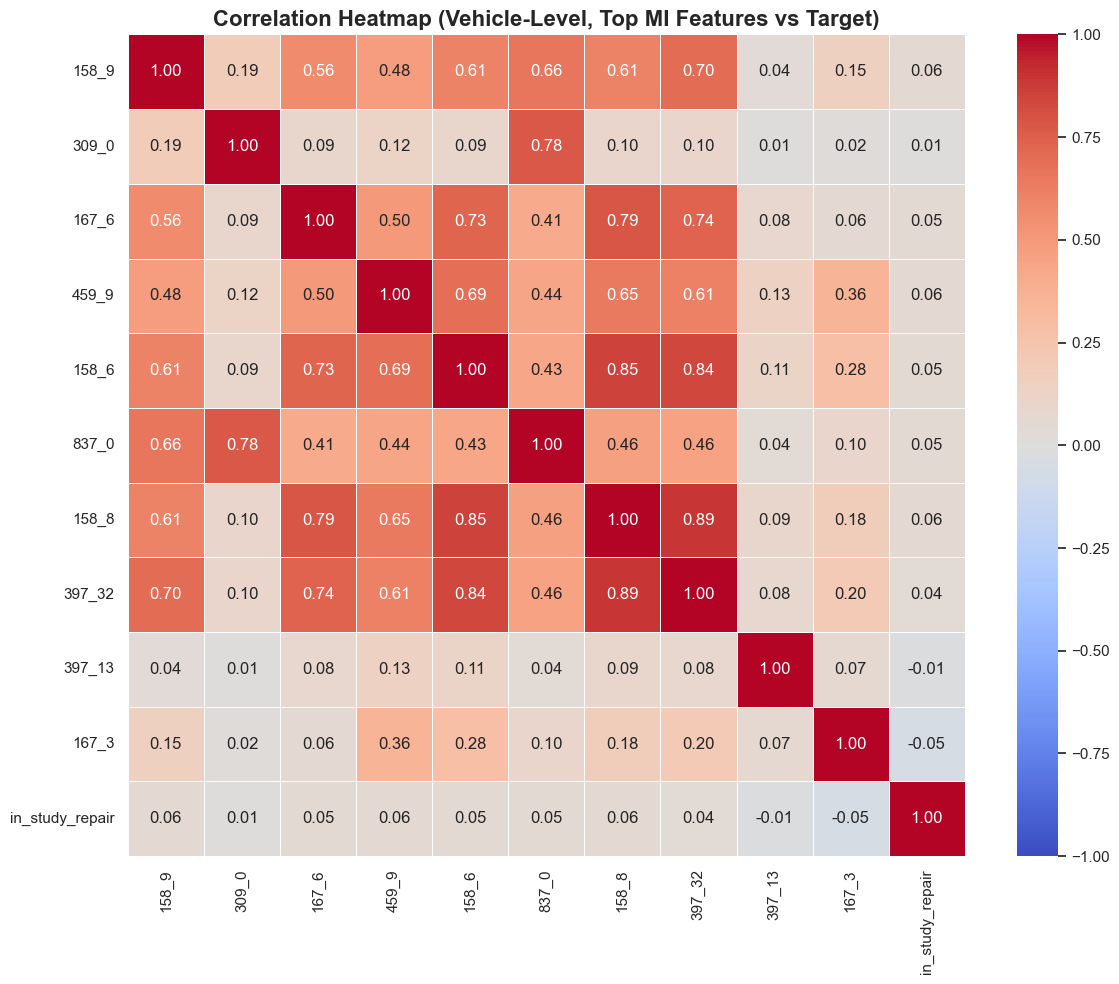

In [27]:
# Analyze collinearity among the top predictors to detect redundant sensors
top_features = mi_scores.head(10).index.tolist()
cols_to_correlate = top_features + ['in_study_repair']

plt.figure(figsize=(12, 10))
corr_matrix = df_vehicle_level[cols_to_correlate].corr()

sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Correlation Heatmap (Vehicle-Level, Top MI Features vs Target)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Domain Drift Analysis (Covariate Shift)
A core challenge in deploying machine learning for industrial fleets is that vehicles operate under diverse configurations and environmental conditions. If the underlying distribution of a highly predictive sensor changes drastically depending on the vehicle's hardware specification, a global static model will fail to generalize.

By integrating the operational data with the technical specifications, we can visualize this phenomenon using Kernel Density Estimation (KDE) plots. Stratifying the distributions of our top sensors by vehicle category provides direct visual proof of **Covariate Shift** across the fleet, justifying the need for advanced Domain Adaptation and Transfer Learning techniques.


Integrating Technical Specifications for Domain Analysis...


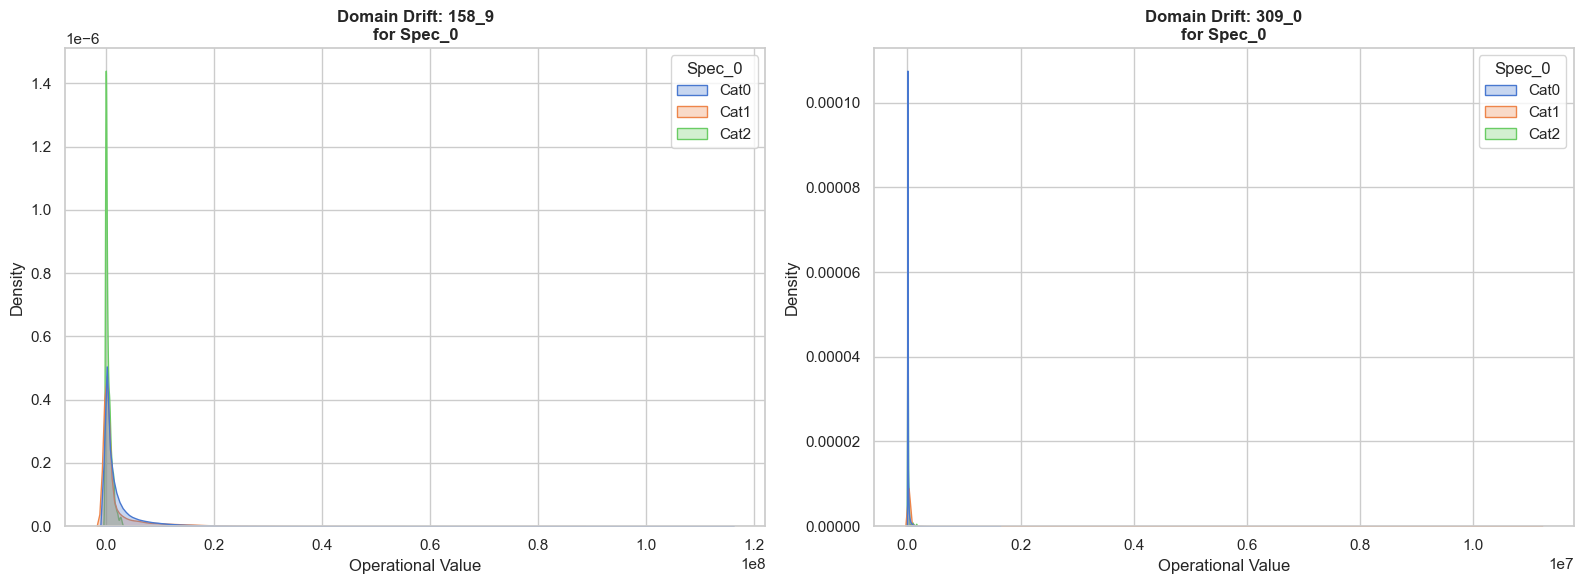

In [28]:
print("Integrating Technical Specifications for Domain Analysis...")

# Merge the integrated dataset (Operational + TTE) with the static technical specifications
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

# Isolate a categorical specification column (e.g., vehicle chassis or weight class)
cat_col_domain = train_specs.select_dtypes(include=['object']).columns[0]

# Select the top 2 features identified via Mutual Information for the drift analysis
features_for_domain = top_features[:2] 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, feature in enumerate(features_for_domain):
    # Generate Kernel Density Estimate (KDE) plots to compare distributions across domains
    sns.kdeplot(
        data=df_full, 
        x=feature, 
        hue=cat_col_domain, 
        ax=axes[i], 
        common_norm=False, 
        fill=True, 
        alpha=0.3
    )
    axes[i].set_title(f'Domain Drift: {feature}\nfor {cat_col_domain}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Operational Value')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


## 7. Feature Engineering and Global Degradation Trajectory
The raw histogram bins measure localized frequencies, but physical wear is cumulative. To capture the overall degradation of a component, we engineer new features by summing the individual bins of a specific histogram family (e.g., the `167` sensor group), effectively calculating the "total exposure" to that operational stressor.

Finally, we isolate the subset of vehicles that experienced a failure and plot this cumulative exposure against the Time-To-Event. By inverting the X-axis, we simulate a countdown to the failure event (TTE = 0), revealing a clear, global trajectory of physical degradation across the fleet.


Engineering histogram-based features...
Created new aggregated feature: 'total_exposure_167' from 10 bins.


,vehicle_id,time_step,total_exposure_167
0,0,11.2,12536776.0
1,0,11.4,12543213.0
2,0,19.6,0.0
3,0,20.2,0.0
4,0,21.0,0.0


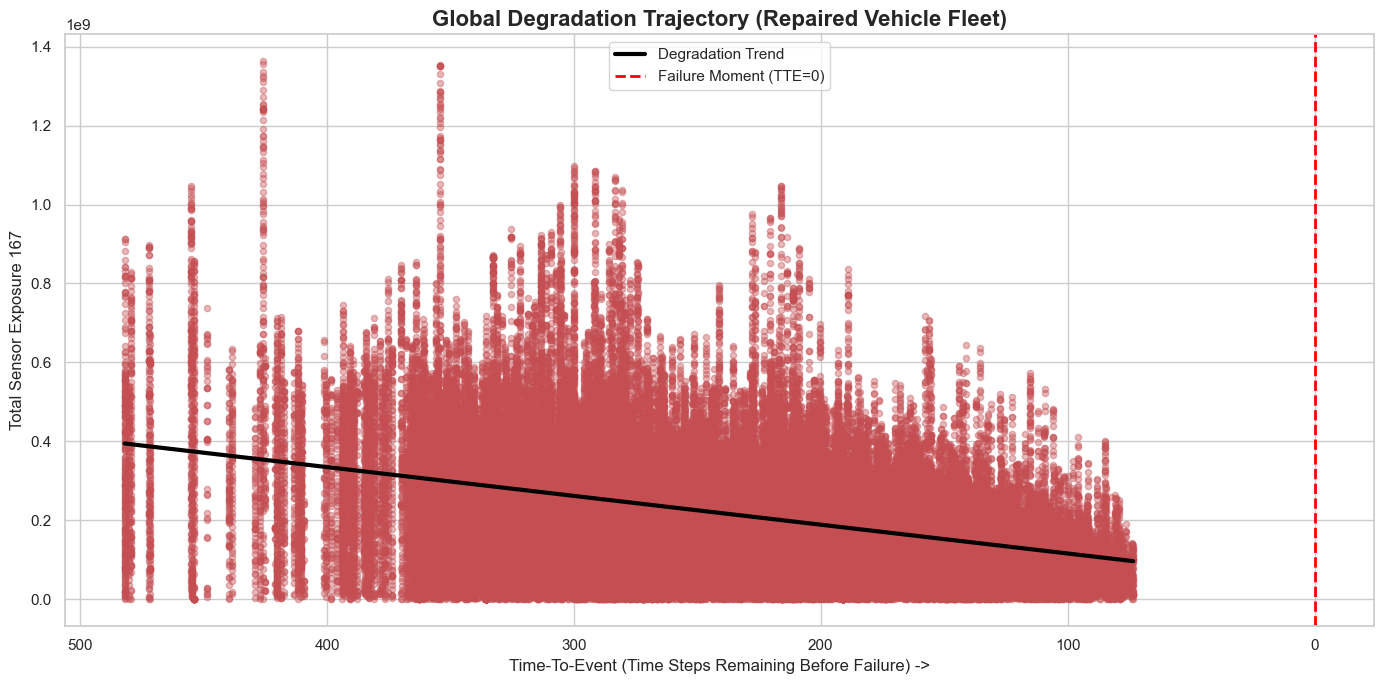

In [29]:
print("Engineering histogram-based features...")

# Define the target histogram prefix (using '167' as an example based on MI findings)
hist_target_name = '167' 
hist_bins = [c for c in df_merged.columns if re.match(rf'^{hist_target_name}_\d+$', c)]

# Engineer a new cumulative feature: the sum of all bins (total exposure time to the stressor)
df_merged[f'total_exposure_{hist_target_name}'] = df_merged[hist_bins].sum(axis=1)

print(f"Created new aggregated feature: 'total_exposure_{hist_target_name}' from {len(hist_bins)} bins.")
display(df_merged[['vehicle_id', 'time_step', f'total_exposure_{hist_target_name}']].head())

# Isolate the operational history of only the vehicles that ultimately failed
df_failed_fleet = df_merged[df_merged['in_study_repair'] == 1].copy()

plt.figure(figsize=(14, 7))

# Plot the scatter distribution and compute a linear regression line to highlight the trend
sns.regplot(
    data=df_failed_fleet,
    x='length_of_study_time_step', 
    y=f'total_exposure_{hist_target_name}',
    scatter_kws={'alpha': 0.4, 'color': '#C44E52', 's': 20}, # Semi-transparent to handle density
    line_kws={'color': 'black', 'linewidth': 3, 'label': 'Degradation Trend'}
)

# Invert the X-axis to visualize the "countdown" effect toward the point of failure
plt.gca().invert_xaxis() 
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Failure Moment (TTE=0)')

plt.title('Global Degradation Trajectory (Repaired Vehicle Fleet)', fontsize=16, fontweight='bold')
plt.xlabel('Time-To-Event (Time Steps Remaining Before Failure) ->', fontsize=12)
plt.ylabel(f'Total Sensor Exposure {hist_target_name}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## 8. EDA Conclusions and Next Steps
The exploratory data analysis of the SCANIA Component X dataset reveals three critical insights that dictate our downstream modeling strategy:
1. **Severe Imbalance & Complex Signatures:** The dataset is heavily dominated by nominal operational data. Component degradation does not follow simple linear trends but manifests as cumulative mechanical stress across specific multi-dimensional histograms (e.g., families `167`, `158`).
2. **Covariate Shift:** The KDE visualizations provide undeniable empirical proof that identical sensors exhibit radically different statistical distributions depending on the vehicle's hardware configuration (Cat0 vs. Cat1 vs. Cat2). 
3. **The Necessity of Domain Adaptation:** The visible divergence in sensor behavior across configurations and lifecycles proves that a single, global predictive model will inevitably fail to generalize across the entire fleet. 

**Next Steps:** In the subsequent notebook, we will programmatically generate specific Source-Target domains, isolate the failure signatures, and rigorously quantify this spatial drift using geometric metrics (SWD, MMD, FD) to mathematically prove its impact on Transfer Learning performance.